In [29]:
import pandas as pd
import os
import torch
from tqdm import tqdm
DATA_DIR = f'{os.path.expanduser("~")}/.delta/nursing_pt'
import math
from lib.datasets import nursing
from torch.utils.data import DataLoader
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

class WindowedDatasetWithStrideAndModeOfLabel(torch.utils.data.Dataset):
    def __init__(self, nurse, windowsize=1, stride=1):
        self.windowsize = windowsize
        self.stride = stride
        self.channels = 3
        self.X,self.y = torch.load(f'{DATA_DIR}/{nurse}.pt')
        self.len = math.ceil(len(self.X)/self.stride)
        
        self.X = torch.cat([self.X,torch.zeros(self.windowsize-1,3)])

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return self.X[(idx*self.stride):(idx*self.stride)+self.windowsize].transpose(0,1),self.y[(idx*self.stride):(idx*self.stride)+self.windowsize].mode().values
def load_nursing_5_class(nurses, winsize, test_size, batch_size, stride=1):
    not_labeled = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10}
    unlabled_sessions = set.intersection(set(nurses), not_labeled)
    if unlabled_sessions:
        raise ValueError(f"Session indexes {unlabled_sessions} are not labled")

    if stride == 'partition':
        stride = winsize
    if test_size == 0:
        train_idx = nurses
        dev_idx = []
    else:
        train_idx, dev_idx = train_test_split(nurses, test_size=test_size, random_state=0)
    print(train_idx,dev_idx)
    trainloader = DataLoader(dataset=ConcatDataset([WindowedDatasetWithStrideAndModeOfLabel(nurse=idx,windowsize=winsize,stride=stride) for idx in train_idx]),batch_size=batch_size,shuffle=True)
    devloader = DataLoader(dataset=ConcatDataset([WindowedDatasetWithStrideAndModeOfLabel(nurse=idx,windowsize=winsize,stride=stride) for idx in dev_idx]),batch_size=batch_size,shuffle=False)
    
    return trainloader, devloader


In [76]:
from torch import nn

def get_padding(l,out_l,k,s,d=1):
    if l % 2 == 0:
        return ((out_l-1)*s - l + d*(k-1))//2 + 1
    return ((out_l-1)*s - l + d*(k-1) + 1)//2 

class XBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, seq_len, b, g, p_dropout=None):
        super().__init__()

        stride = 1
        self.seq_len = seq_len
        if out_channels > in_channels:
            stride = 2
            self.seq_len = seq_len // 2 if seq_len % 2 == 0 else seq_len // 2 + 1

        padding = get_padding(seq_len, self.seq_len, kernel_size, stride)
        
        self.c = nn.Sequential(
            nn.Conv1d(in_channels, in_channels // b, kernel_size=1, padding=0),
            nn.LayerNorm((seq_len)),
            nn.ReLU(),
            nn.Conv1d(in_channels // b, in_channels // b, kernel_size=kernel_size, padding=padding, groups=g, stride=stride),
            nn.LayerNorm((self.seq_len)),
            nn.ReLU(),
            nn.Conv1d(in_channels // b, out_channels, kernel_size=1, padding=0),
            nn.LayerNorm((self.seq_len)),
            nn.ReLU()
        )
        if p_dropout is not None and p_dropout > 0:
            self.c.add_module('dropout', nn.Dropout(p=p_dropout))
        
        self.identity = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=1, padding=0, stride=stride),
            nn.LayerNorm((self.seq_len)),
            nn.ReLU()
        ) if out_channels > in_channels else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.identity(x) + self.c(x))
    
class RegNet(nn.Module):
    def __init__(self, winsize, in_channels, stem_out_c, d: list, w: list, b, g, p_dropout=None):
        """
            stem_out_c: out channels of stem before first stage
            d: tuple of num blocks in each stage
            w: tuple of num channels in each stage
        """        
        super().__init__()
        self.winsize = winsize
        self.in_channels = in_channels
        self.stem_out_c = stem_out_c
        self.n_stage = len(d)
        if len(w) != len(d):
            raise ValueError('d and w must have same length')
        
        self.d_str = '-'.join([str(di) for di in d])
        self.w_str = '-'.join([str(wi) for wi in w])
        self.g = g
        self.b = b
        self.p_dropout = p_dropout

        s = nn.Sequential()
        w = [stem_out_c] + list(w)

        stem_pre_ln = math.floor(((winsize-1))/2+1)
        stem_out_len = math.floor(((stem_pre_ln-3))/2+1)
        
        for i in range(self.n_stage):
            rs = nn.Sequential()
            for j in range(d[i]):
                rs.add_module(f'stage-{i}_block-{j}', XBlock(
                    w[i] if j==0 else w[i+1], 
                    w[i+1], 
                    kernel_size=3, 
                    seq_len=rs[-1].seq_len if j>0 else s[-1][-1].seq_len if i>0 else stem_out_len, 
                    b=b, 
                    g=g, 
                    p_dropout=p_dropout
                ))
            s.add_module(f'stage-{i}', rs)

        self.e = nn.Sequential(
            nn.Conv1d(in_channels, stem_out_c, kernel_size=3, stride=2, padding=1),
            nn.LayerNorm((stem_pre_ln)),
            nn.MaxPool1d(kernel_size=2,stride=2),
            nn.ReLU(),
            s
        )

        self.o = nn.Sequential(
            nn.AvgPool1d(kernel_size=rs[-1].seq_len if rs else stem_out_len), # Nxdims[-1]x1
            nn.Flatten(start_dim=1), # Nxdims[-1]
            nn.Linear(in_features=w[-1], out_features=5)
        )

    def forward(self, x):
        x = x.view(-1, self.in_channels, self.winsize)
        x = self.e(x)
        x = self.o(x)
        return x

In [77]:
CONFIG = {
    'WINDOW_SIZE':3901,
    'BATCH_SIZE':512,
    'LEARNING_RATE':3e-4,
    'TEST_SIZE':0.25,
    'DEVICE':'cuda',
    'DEPTHI':[1,1],
    'WIDTHI':[32,64],
}
import json
with open('config.json','w') as f:
    json.dump(CONFIG,f)
    
trainloader, devloader = load_nursing_5_class(range(11,71), CONFIG['WINDOW_SIZE'], test_size=CONFIG['TEST_SIZE'], batch_size=CONFIG['BATCH_SIZE'],stride=CONFIG['WINDOW_SIZE'])

[54, 60, 18, 25, 43, 61, 40, 53, 65, 29, 67, 38, 26, 16, 42, 27, 62, 31, 63, 19, 24, 36, 48, 28, 56, 59, 68, 49, 12, 23, 57, 35, 17, 34, 47, 32, 30, 20, 50, 66, 14, 11, 64, 58, 55] [37, 46, 70, 39, 22, 13, 45, 69, 51, 33, 15, 21, 41, 52, 44]


In [78]:

model = RegNet(winsize=CONFIG['WINDOW_SIZE'],in_channels=3,stem_out_c=32,d=CONFIG['DEPTHI'],w=CONFIG['WIDTHI'],b=1,g=2)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=CONFIG['LEARNING_RATE'])
model.to(CONFIG['DEVICE'])
criterion.to(CONFIG['DEVICE'])

CrossEntropyLoss()

In [79]:
Xi,yi = next(iter(trainloader))
lossi = []

In [80]:
from tqdm import tqdm
from lib.utils import evaluate
from sklearn.metrics import f1_score
model.train()
for i in range(20):
    for (X_tr,y_tr) in tqdm(trainloader,leave=False):
        X_tr,y_tr = X_tr.to(CONFIG['DEVICE']),y_tr.to(CONFIG['DEVICE'])
        logits = model(X_tr)
        loss = criterion(logits,y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lossi.append(loss.item())

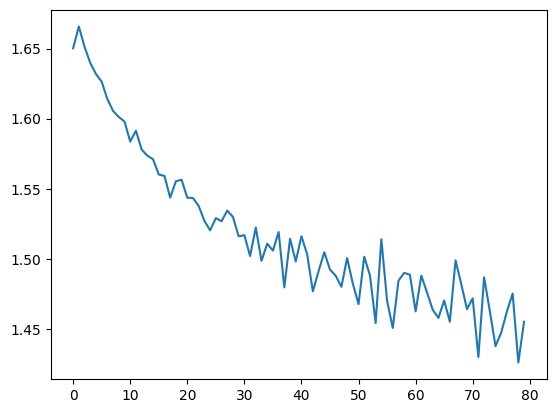

In [81]:
import matplotlib.pyplot as plt
plt.plot(lossi)